# Task 1: Resolution of the Rate Equations


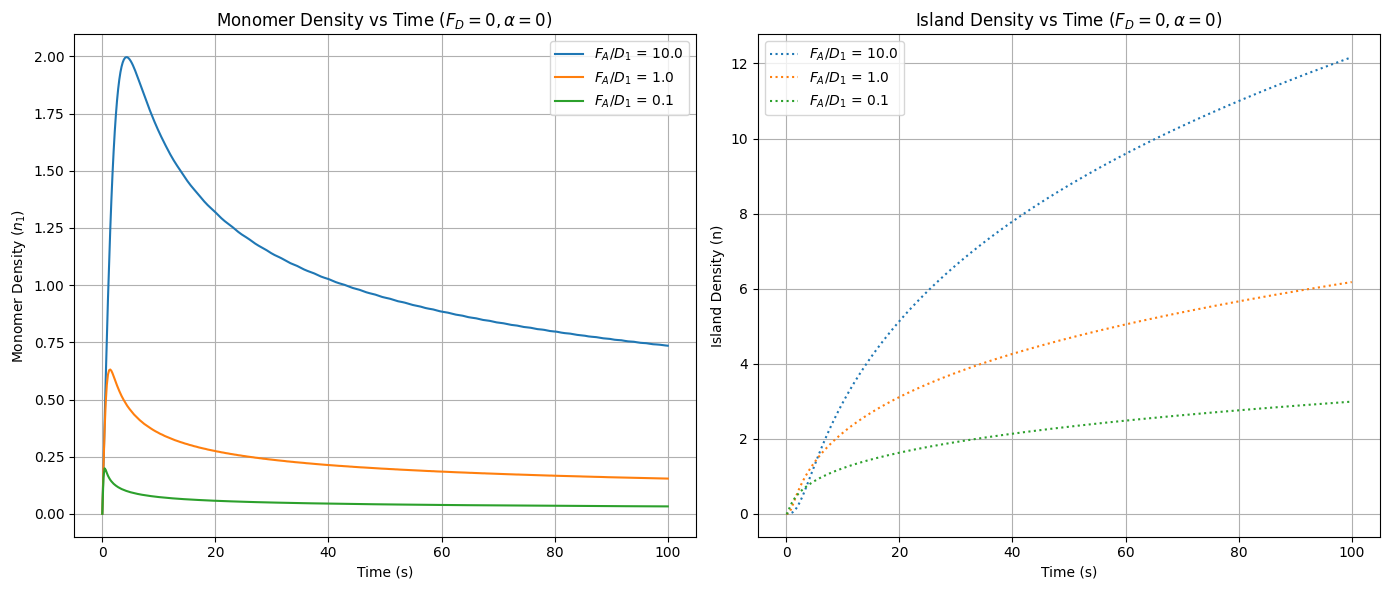

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the system of rate equations
def rate_equations(t, y, FA, D1, FD, alpha):
    # y[0] is n1 (monomer density), y[1] is n (island density)
    n1, n = y
    # Equation 1: Rate of change of monomer density
    dn1_dt = FA - FD - 2 * D1 * n1**2 - D1 * n1 * n - 2 * alpha * FA * n1 - alpha * FA * n
    # Equation 2: Rate of change of island density
    dn_dt = D1 * n1**2 + alpha * FA * n1
    return [dn1_dt, dn_dt]

# Initial conditions and parameters
n1_0 = 0.0  # Initial monomer density
n_0 = 0.0   # Initial island density
y0 = [n1_0, n_0]

# Time array for integration
t_span = (0, 100)  # Time range for the simulation
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Constants for Task 1a
FA = 1         # Constant deposition rate
FD = 0         # Death rate of monomers
alpha = 0      # No direct impingement

# Test different FA/D1 ratios by varying D1
D1_values = [0.1, 1, 10]
solutions = []

# Solve the system for each D1 value
for D1 in D1_values:
    sol = solve_ivp(rate_equations, t_span, y0, args=(FA, D1, FD, alpha), t_eval=t_eval, method='RK45')
    solutions.append(sol)

# Plotting results for Task 1a
plt.figure(figsize=(14, 6))
for idx, sol in enumerate(solutions):
    plt.subplot(1, 2, 1)
    plt.plot(sol.t, sol.y[0], label=rf'$F_A/D_1$ = {FA/D1_values[idx]}')
    #plt.plot(sol.t, sol.y[1], ":",label=f'n1 FA/D1 = {FA/D1_values[idx]}')
    plt.xlabel('Time (s)')
    plt.ylabel(r'Monomer Density ($n_1$)')
    plt.title(r'Monomer Density vs Time ($F_D=0, \alpha=0$) ')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(sol.t, sol.y[1], ":",label=rf'$F_A/D_1$ = {FA/D1_values[idx]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Island Density (n)')
    plt.title(r'Island Density vs Time ($F_D=0, \alpha=0$)')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()


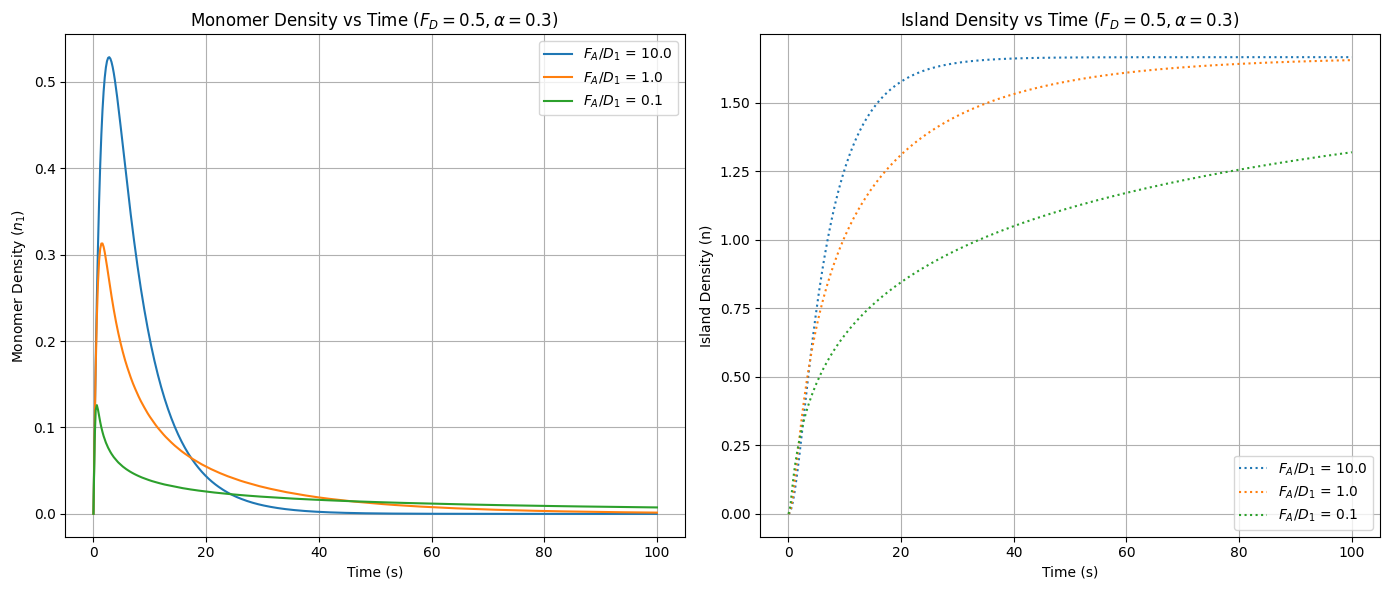

In [4]:
# Update constants for Task 1b
FD = 0.5       # Death rate of monomers
alpha = 0.3    # Direct impingement rate

# Solve the system for each D1 value under the new conditions
solutions_1b = []
for D1 in D1_values:
    sol = solve_ivp(rate_equations, t_span, y0, args=(FA, D1, FD, alpha), t_eval=t_eval, method='RK45')
    solutions_1b.append(sol)

# Plotting results for Task 1b
plt.figure(figsize=(14, 6))
for idx, sol in enumerate(solutions_1b):
    plt.subplot(1, 2, 1)
    plt.plot(sol.t, sol.y[0], label=rf'$F_A/D_1$ = {FA/D1_values[idx]}')
    #plt.plot(sol.t, sol.y[1], ":",label=f'n1 FA/D1 = {FA/D1_values[idx]}')
    plt.xlabel('Time (s)')
    plt.ylabel(r'Monomer Density ($n_1$)')
    plt.title(r'Monomer Density vs Time ($F_D=0.5, \alpha=0.3$) ')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(sol.t, sol.y[1], ":",label=rf'$F_A/D_1$ = {FA/D1_values[idx]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Island Density (n)')
    plt.title(r'Island Density vs Time ($F_D=0.5, \alpha=0.3$)')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()